[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/05_puerto_rico_preregistered_test.ipynb)

# Puerto Rico test of physics-informed deep-state inference (USGS Utuado and Toro Negro, 2018–2020)

**Question.** Given only a shallow soil-moisture probe and rain, can a calibrated physics model (1-D Richards) infer soil moisture near the failure plane better than a physics-guided MLP?

**Pre-registration.** `PREREGISTRATION.md` was frozen before any storm catalogue or model result was computed; its SHA-256 is in `PREREG_SHA256.txt` and is re-checked below. All changes are listed in `DEVIATIONS.md`. Registered tests are labelled *registered*; everything else is *exploratory*.

**Data.** `utuado_15min.csv`, `toroNegro_15min.csv` (USGS hillslope monitoring stations, 15-min, five soil-moisture depths, piezometers, rain) and `PuertoRico_TestingData.xlsx` (lab van Genuchten parameters). They are in `data/puerto_rico/` of this repository (source: USGS data release, https://doi.org/10.5066/P9548YK2).

The heavy runs (solver calibration, ~5 h on 2 CPU cores) are the scripts written below; this notebook loads their stored outputs from `out/`. Set `RUN_ALL = True` to recompute everything.

In [1]:
import os, sys, json, hashlib, subprocess, warnings
warnings.filterwarnings('ignore')
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here)), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, 'puerto_rico')); sys.path.insert(0, os.getcwd())
for _pkg, _mod in [('numpyro', 'numpyro'), ('optax', 'optax'), ('openpyxl', 'openpyxl')]:
    try: __import__(_mod)
    except ImportError: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=True)
print('repository:', ROOT, '| working folder:', os.getcwd())
try:
    import jax, optax
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'jax[cpu]', 'optax', 'openpyxl'], check=True)
import numpy as np, pandas as pd
RUN_ALL = False
h = hashlib.sha256(open('PREREGISTRATION.md', 'rb').read()).hexdigest()
print('pre-registration hash matches frozen value:', h == open('PREREG_SHA256.txt').read().split()[0])
print(open('PREREGISTRATION.md').read()); print(open('DEVIATIONS.md').read())

repository: /content/SAVE-LEWS | working folder: /content/SAVE-LEWS/puerto_rico
pre-registration hash matches frozen value: True
# Pre-registration — Puerto Rico two-depth test of physics-informed inference

Frozen: 2026-09-27 (Asia/Bangkok), before any storm catalogue, lag statistic or model result was computed.
At this point only file headers, column names and the lab workbook (van Genuchten parameters) had been inspected.
The SHA-256 of this file is recorded in PREREG_SHA256.txt immediately after writing. Any analysis not listed here is exploratory.

## Data
- Utuado station (coarse SM soil, 42°): 15-min series 2018-07-12 to 2020-06-01. VWC at 12, 27, 42, 57, 72 cm; tensiometers 62/78 cm; piezometers 40/55 cm; rain.
- Toro Negro station (fine CL/MH soil, 45°; lab samples labelled ELT): 15-min series 2018-07-12 to 2020-04-12. VWC sp1 at 30, 50, 70, 90, 110 cm; piezometers 83/126 cm; rain.
- Lab: drying and wetting van Genuchten parameters and Ksat for UTU (3 depths) and ELT (2 depths

## 1. Code
All analysis code is in `puerto_rico/*.py` of this repository (data loader `pr_data.py`, JAX Richards solver `richards_jax.py`, calibration `p1_physics.py`, runners `run_*.py`, evaluation `eval_*.py`).

In [2]:
if RUN_ALL:
    for site in ['utuado', 'toronegro']:
        for s in ['run_p1_physics.py', 'run_p1_se.py', 'run_p1_mlp.py']:
            subprocess.run([sys.executable, s, site], check=True)
        for m in ['cal', 'se']:
            subprocess.run([sys.executable, 'run_p4.py', site, m], check=True)
subprocess.run([sys.executable, 'p2_lag.py'], check=True, capture_output=True)
subprocess.run([sys.executable, 'eval_p1.py'], check=True, capture_output=True)
subprocess.run([sys.executable, 'explore_72.py'], check=True, capture_output=True)
subprocess.run([sys.executable, 'eval_p4.py'], check=True, capture_output=True)
print('evaluations refreshed from stored predictions')

evaluations refreshed from stored predictions


## 2. Data and storms

In [3]:
from pr_data import SITES, load, storms
rows = []
for site in SITES:
    d = load(site); S = storms(d); c = SITES[site]
    for z, col in c['profile'].items():
        v = d[col]; rows.append(dict(site=site, depth_m=z, missing=round(v.isna().mean(), 3), p5=round(v.quantile(.05), 3), p95=round(v.quantile(.95), 3)))
    print(site, d.index.min().date(), '→', d.index.max().date(), '| storms >= 10 mm:', len(S), '| rain', round(d.rain.sum()), 'mm')
pd.DataFrame(rows)

utuado 2018-07-12 → 2020-06-01 | storms >= 10 mm: 96 | rain 2853 mm


toronegro 2018-07-12 → 2020-04-12 | storms >= 10 mm: 84 | rain 3322 mm


,site,depth_m,missing,p5,p95
0,utuado,0.12,0.187,0.171,0.402
1,utuado,0.27,0.052,0.107,0.360
2,utuado,0.42,0.052,0.143,0.372
3,utuado,0.57,0.052,0.096,0.327
4,utuado,0.72,0.052,0.059,0.282
5,toronegro,0.30,0.000,0.514,0.526
6,toronegro,0.50,0.000,0.471,0.479
7,toronegro,0.70,0.000,0.425,0.461
8,toronegro,0.90,0.602,0.371,0.445
9,toronegro,1.10,0.000,0.428,0.458


## 3. P2 — how fast does water reach depth? (registered)

In [4]:
p2 = json.load(open('res_p2.json')); pd.DataFrame({(s, k): v for s in p2 for k, v in p2[s].items()}).T

z storms_with_data shallow_rises deep_rises both_rise  \
utuado    deep   0.72               96            89         71        71   
          deep2  0.57               96            89         86        86   
toronegro deep    0.9               84             5         46         2   
          deep2   1.1               84             5         73         5   

                median_lag_h             iqr_h frac_le_30min  \
utuado    deep           2.0      [0.75, 6.75]      0.225352   
          deep2        1.125       [0.5, 7.75]      0.383721   
toronegro deep         0.375  [0.3125, 0.4375]           1.0   
          deep2       -21.75    [-24.75, 0.25]           1.0   

                frac_deep_before_shallow  
utuado    deep                  0.070423  
          deep2                  0.05814  
toronegro deep                       0.0  
          deep2                      0.6

Decision rule: median lag > 2 h → matrix-dominated; median ≤ 30 min or > 50% of storms ≤ 30 min → preferential flow reaches depth.

## 4. P1 — virtual deep sensor (registered test = R-cal, primary depth)

In [5]:
r = json.load(open('out/p1_report.json'))
for site in r:
    for which in ('primary', 'secondary'):
        print(site, which, r[site][which]['n_storms'], 'storms'); display(pd.Series(r[site][which]['skill']).round(3).to_frame('skill'))
    rows = []
    for k, v in r[site]['primary'].items():
        if 'minus' in k:
            for s, d in v.items(): rows.append(dict(comparison=k, mlp_seed=s, diff=round(d['diff'], 3), ci_low=round(d['ci95'][0], 3), ci_high=round(d['ci95'][1], 3)))
    display(pd.DataFrame(rows))

utuado primary 89 storms


,skill
R-cal,0.004
R-lab,-1.268
R-cal-Se (exploratory),0.170
PG-MLP s0,0.389
PG-MLP s1,0.313
PG-MLP s2,0.340


utuado secondary 89 storms


,skill
R-cal,0.492
R-lab,0.247
R-cal-Se (exploratory),0.665
PG-MLP s0,0.485
PG-MLP s1,0.448
PG-MLP s2,0.461


,comparison,mlp_seed,diff,ci_low,ci_high
0,R-cal minus PG-MLP,0,-0.384,-0.702,-0.101
1,R-cal minus PG-MLP,1,-0.309,-0.666,0.041
2,R-cal minus PG-MLP,2,-0.336,-0.670,-0.047
3,R-lab minus PG-MLP,0,-1.657,-2.791,-1.032
4,R-lab minus PG-MLP,1,-1.582,-2.670,-0.987
5,R-lab minus PG-MLP,2,-1.609,-2.737,-0.980
6,R-cal-Se (exploratory) minus PG-MLP,0,-0.219,-0.460,-0.031
7,R-cal-Se (exploratory) minus PG-MLP,1,-0.143,-0.407,0.106
8,R-cal-Se (exploratory) minus PG-MLP,2,-0.170,-0.421,0.016


toronegro primary 51 storms


,skill
R-cal,-1.159
R-lab,-7.682
R-cal-Se (exploratory),-0.256
PG-MLP s0,0.730
PG-MLP s1,0.708
PG-MLP s2,0.715


toronegro secondary 51 storms


,skill
R-cal,-0.282
R-lab,-15.448
R-cal-Se (exploratory),-0.252
PG-MLP s0,0.615
PG-MLP s1,0.613
PG-MLP s2,0.605


,comparison,mlp_seed,diff,ci_low,ci_high
0,R-cal minus PG-MLP,0,-1.889,-3.252,-1.099
1,R-cal minus PG-MLP,1,-1.867,-3.241,-1.086
2,R-cal minus PG-MLP,2,-1.874,-3.237,-1.082
3,R-lab minus PG-MLP,0,-8.412,-13.084,-5.774
4,R-lab minus PG-MLP,1,-8.389,-13.298,-5.769
5,R-lab minus PG-MLP,2,-8.396,-13.140,-5.804
6,R-cal-Se (exploratory) minus PG-MLP,0,-0.987,-1.282,-0.804
7,R-cal-Se (exploratory) minus PG-MLP,1,-0.964,-1.252,-0.777
8,R-cal-Se (exploratory) minus PG-MLP,2,-0.971,-1.256,-0.785


### Exploratory: 57 cm at Utuado, perched saturation, 72 cm peak size

In [6]:
print(json.dumps(json.load(open('out/explore_72.json')), indent=1))

{
 "R-cal minus PG-MLP @57cm": {
  "0": [
   0.008,
   [
    -0.118,
    0.181
   ]
  ],
  "1": [
   0.044,
   [
    -0.08,
    0.198
   ]
  ],
  "2": [
   0.032,
   [
    -0.091,
    0.194
   ]
  ]
 },
 "R-cal-Se (exploratory) minus PG-MLP @57cm": {
  "0": [
   0.18,
   [
    0.073,
    0.308
   ]
  ],
  "1": [
   0.217,
   [
    0.095,
    0.342
   ]
  ],
  "2": [
   0.204,
   [
    0.089,
    0.333
   ]
  ]
 },
 "perched_saturation": {
  "pwp_40cm_kPa": {
   "windows": 89,
   "frac_windows_with_positive_pressure": 0.0
  },
  "pwp_55cm_kPa": {
   "windows": 89,
   "frac_windows_with_positive_pressure": 0.0
  }
 },
 "72cm_peak_rise_model_over_obs": {
  "windows": 63,
  "median": 0.89,
  "q25_q75": [
   0.56,
   1.16
  ]
 }
}


### P3 — calibrated vs lab parameters

In [7]:
pd.concat({s: pd.DataFrame({k: v for k, v in r[s]['P3a'].items() if k != 'lab_range'}) for s in r}, axis=1)

utuado  \
                                                                 R-cal   
fold_median          {'Ks': 0.00025421125246718535, 'alpha': 0.0011...   
between_fold_sd_log  {'Ks': 0.5522023114422313, 'alpha': 0.11860741...   
within_lab_bounds              {'Ks': True, 'alpha': False, 'n': True}   

                                                                        \
                                                R-cal-Se (exploratory)   
fold_median          {'Ks': 0.010000353759415012, 'alpha': 0.099893...   
between_fold_sd_log  {'Ks': 0.2942537043872295, 'alpha': 0.74549656...   
within_lab_bounds               {'Ks': True, 'alpha': True, 'n': True}   

                                                             toronegro  \
                                                                 R-cal   
fold_median          {'Ks': 0.001201116597861149, 'alpha': 0.030448...   
between_fold_sd_log  {'Ks': 0.21153327944083808, 'alpha': 0.1270528...   
within_lab_bounds              {'Ks': False, 'alpha': True, 'n': True}   

                                                                        
                                                R-cal-Se (exploratory)  
fold_median          {'Ks': 0.0001338918162765057, 'alpha': 0.01404...  
between_fold_sd_log  {'Ks': 0.5321548845071, 'alpha': 0.51989446788...  
within_lab_bounds              {'Ks': True, 'alpha': True, 'n': False}

In [8]:
for site in ['utuado', 'toronegro']:
    for f in [f'out/p1_physics_{site}.json', f'out/p1_se_{site}.json']:
        J = json.load(open(f))
        display(pd.DataFrame([dict(block=x['block'], start=x['start'], loss_first=x['lm_hist'][0], loss_last=x['lm_hist'][-1],
                                   **{k: x['params'][k] for k in ('Ks', 'alpha', 'n')}) for x in J['folds']]).assign(run=f).round(5))

,block,start,loss_first,loss_last,Ks,alpha,n,run
0,0,3,0.00233,0.00196,0.00051,0.00116,1.40607,out/p1_physics_utuado.json
1,1,3,0.00229,0.00193,0.00020,0.00100,1.59706,out/p1_physics_utuado.json
2,2,3,0.00228,0.00193,0.00027,0.00100,1.52101,out/p1_physics_utuado.json
3,3,0,0.00170,0.00128,0.00013,0.00100,1.39715,out/p1_physics_utuado.json
4,4,3,0.00224,0.00181,0.00010,0.00107,1.81004,out/p1_physics_utuado.json
5,5,3,0.00226,0.00186,0.00040,0.00128,1.46050,out/p1_physics_utuado.json
6,6,3,0.00226,0.00194,0.00015,0.00100,1.65675,out/p1_physics_utuado.json
7,7,3,0.00224,0.00190,0.00048,0.00131,1.44691,out/p1_physics_utuado.json
8,8,3,0.00233,0.00197,0.00041,0.00126,1.49657,out/p1_physics_utuado.json
9,9,3,0.00234,0.00190,0.00024,0.00133,1.57133,out/p1_physics_utuado.json


,block,start,loss_first,loss_last,Ks,alpha,n,run
0,0,4,0.01569,0.01559,0.01001,0.09980,1.30151,out/p1_se_utuado.json
1,1,4,0.01566,0.01565,0.01000,0.09999,1.30003,out/p1_se_utuado.json
2,2,4,0.01530,0.01529,0.01000,0.10010,1.30008,out/p1_se_utuado.json
3,3,1,0.01130,0.00783,0.01352,0.00819,1.19441,out/p1_se_utuado.json
4,4,4,0.01584,0.01584,0.01000,0.10000,1.30000,out/p1_se_utuado.json
5,5,4,0.01537,0.01537,0.01000,0.09965,1.30021,out/p1_se_utuado.json
6,6,4,0.01580,0.01580,0.00999,0.09999,1.30022,out/p1_se_utuado.json
7,7,1,0.01453,0.01407,0.00407,0.07487,1.48741,out/p1_se_utuado.json
8,8,4,0.01634,0.01628,0.01002,0.09917,1.30021,out/p1_se_utuado.json
9,9,4,0.01529,0.01529,0.01000,0.10000,1.30000,out/p1_se_utuado.json


,block,start,loss_first,loss_last,Ks,alpha,n,run
0,0,2,0.00052,0.00051,0.00106,0.03049,1.49775,out/p1_physics_toronegro.json
1,1,2,0.00056,0.00055,0.00132,0.03910,1.51538,out/p1_physics_toronegro.json
2,2,2,0.00057,0.00057,0.00100,0.03002,1.50005,out/p1_physics_toronegro.json
3,3,2,0.00055,0.00052,0.00182,0.04125,1.52008,out/p1_physics_toronegro.json
4,4,2,0.00054,0.00052,0.00136,0.03169,1.48896,out/p1_physics_toronegro.json
5,5,2,0.00054,0.00053,0.00100,0.03002,1.50001,out/p1_physics_toronegro.json
6,6,2,0.00044,0.00043,0.00160,0.02858,1.48394,out/p1_physics_toronegro.json
7,7,2,0.00047,0.00044,0.00108,0.03041,1.50468,out/p1_physics_toronegro.json


,block,start,loss_first,loss_last,Ks,alpha,n,run
0,0,0,0.05983,0.05983,0.00007,0.01900,1.35008,out/p1_se_toronegro.json
1,1,4,0.05523,0.05522,0.00010,0.01000,2.00015,out/p1_se_toronegro.json
2,2,4,0.06246,0.06086,0.00011,0.00854,2.05808,out/p1_se_toronegro.json
3,3,4,0.06330,0.05958,0.00042,0.04674,1.99630,out/p1_se_toronegro.json
4,4,4,0.04896,0.04284,0.00016,0.01146,2.20939,out/p1_se_toronegro.json
5,5,4,0.05337,0.05236,0.00011,0.00970,2.03356,out/p1_se_toronegro.json
6,6,4,0.06244,0.05751,0.00022,0.01663,2.05045,out/p1_se_toronegro.json
7,7,4,0.04526,0.04498,0.00020,0.01916,2.00137,out/p1_se_toronegro.json


## 5. P4 — calibrated uncertainty (registered: R-cal Laplace)

In [9]:
pd.concat({s: pd.DataFrame({k: v for k, v in d.items() if k != 'n_windows'}).T for s, d in json.load(open('out/p4_report.json')).items()}).round(4)

coverage   width  interval_score  \
utuado    R-cal Laplace (registered)        0.9530  0.2041          0.2576   
          R-cal-Se Laplace (exploratory)    0.9089  0.1535          0.2362   
          PG-MLP s0 + cross-conformal       0.8969  0.1276          0.2438   
toronegro R-cal Laplace (registered)        0.8663  0.1097          0.1634   
          R-cal-Se Laplace (exploratory)    0.8630  0.0719          0.1133   
          PG-MLP s0 + cross-conformal       0.8880  0.0383          0.0509   

                                           skill        n  
utuado    R-cal Laplace (registered)     -0.1458  36095.0  
          R-cal-Se Laplace (exploratory)  0.1649  36095.0  
          PG-MLP s0 + cross-conformal     0.3890  36019.0  
toronegro R-cal Laplace (registered)     -1.1938  21459.0  
          R-cal-Se Laplace (exploratory) -0.2531  21459.0  
          PG-MLP s0 + cross-conformal     0.7304  21459.0

## 6. Figures

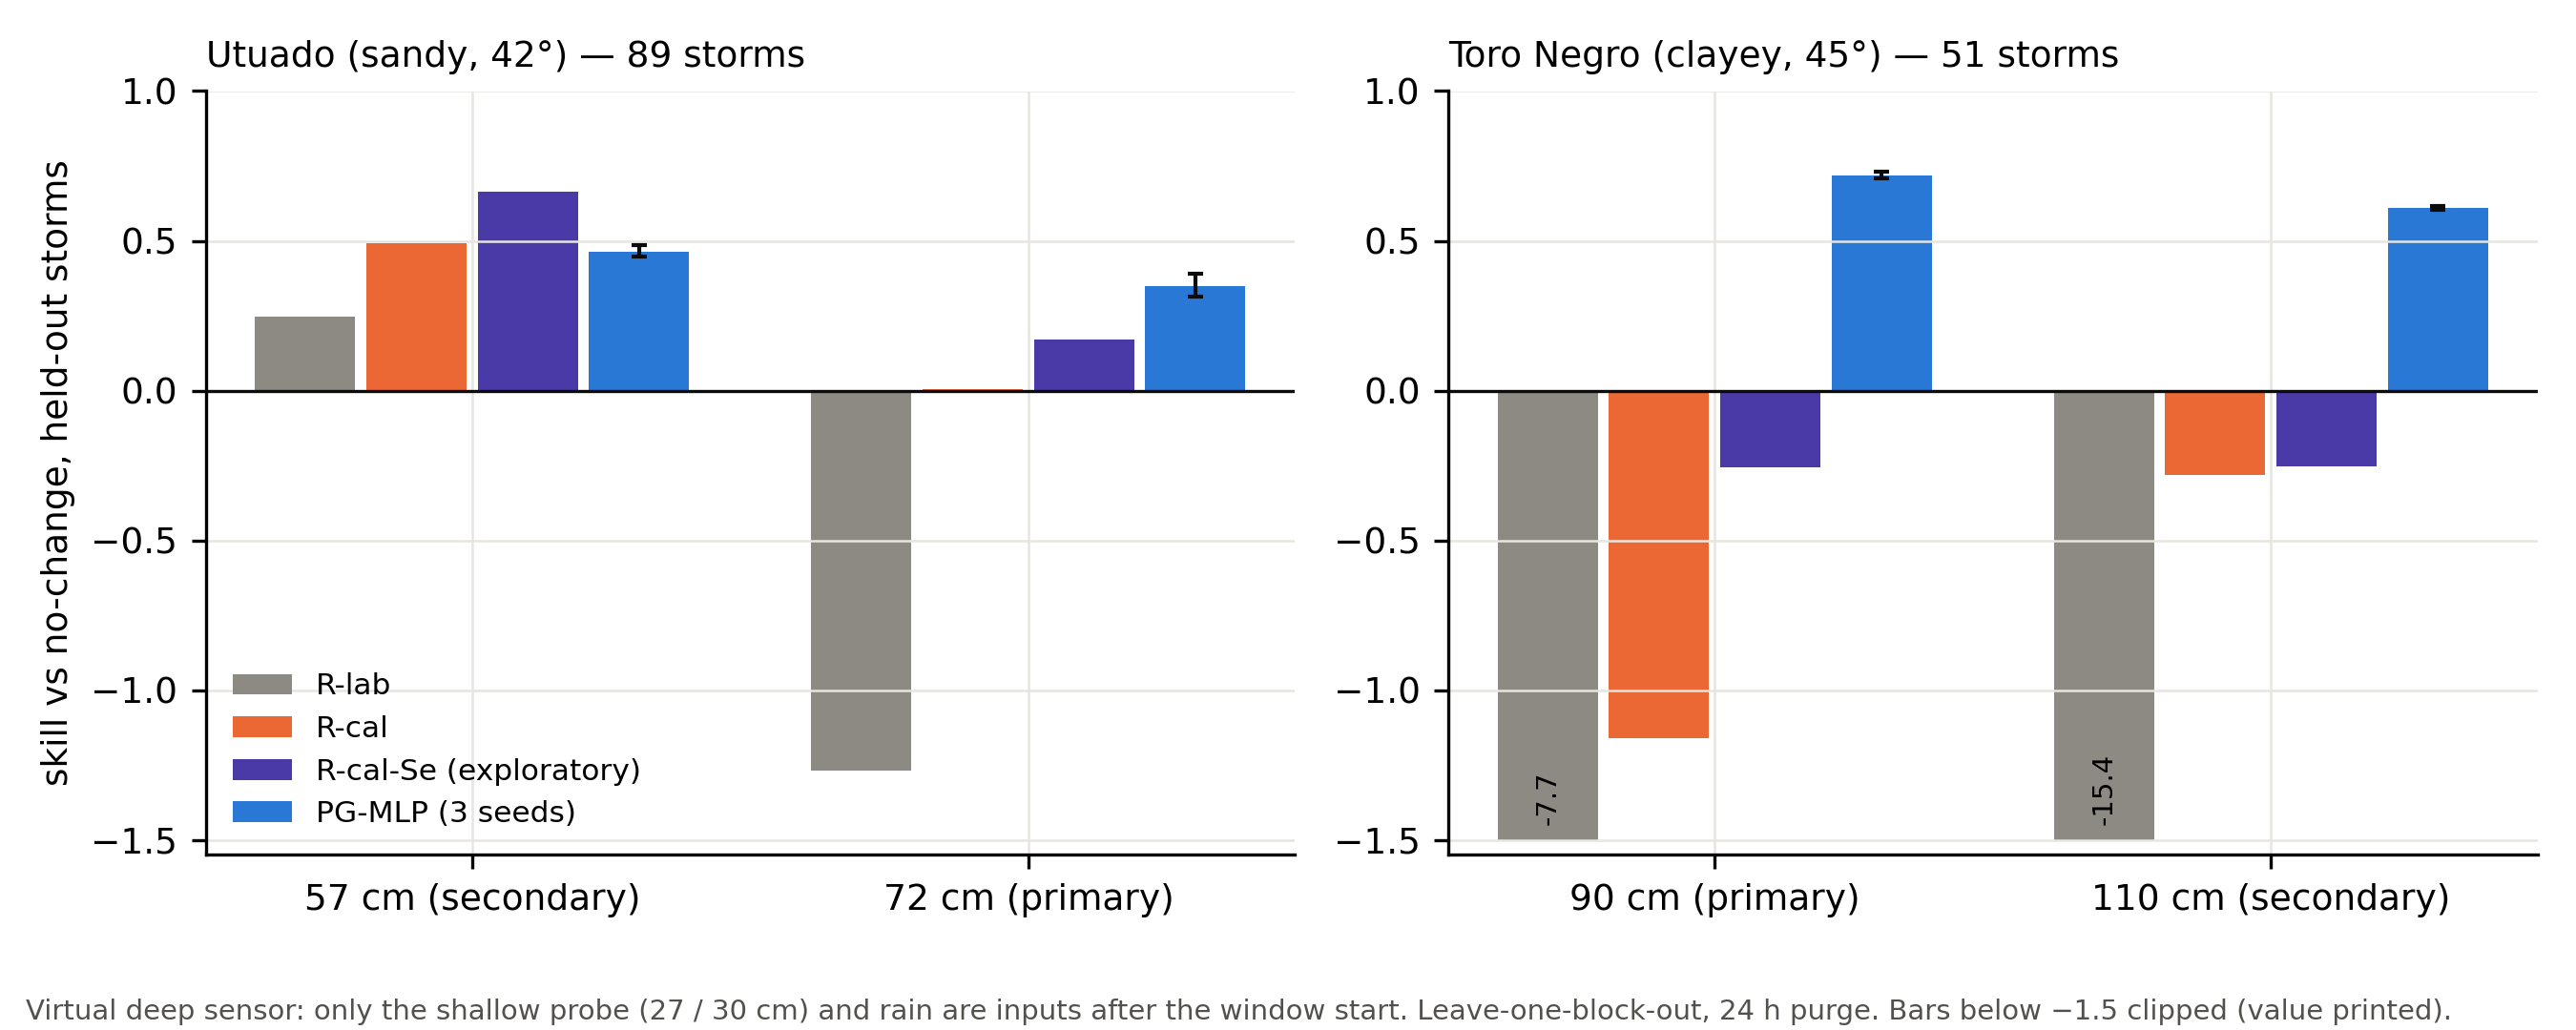

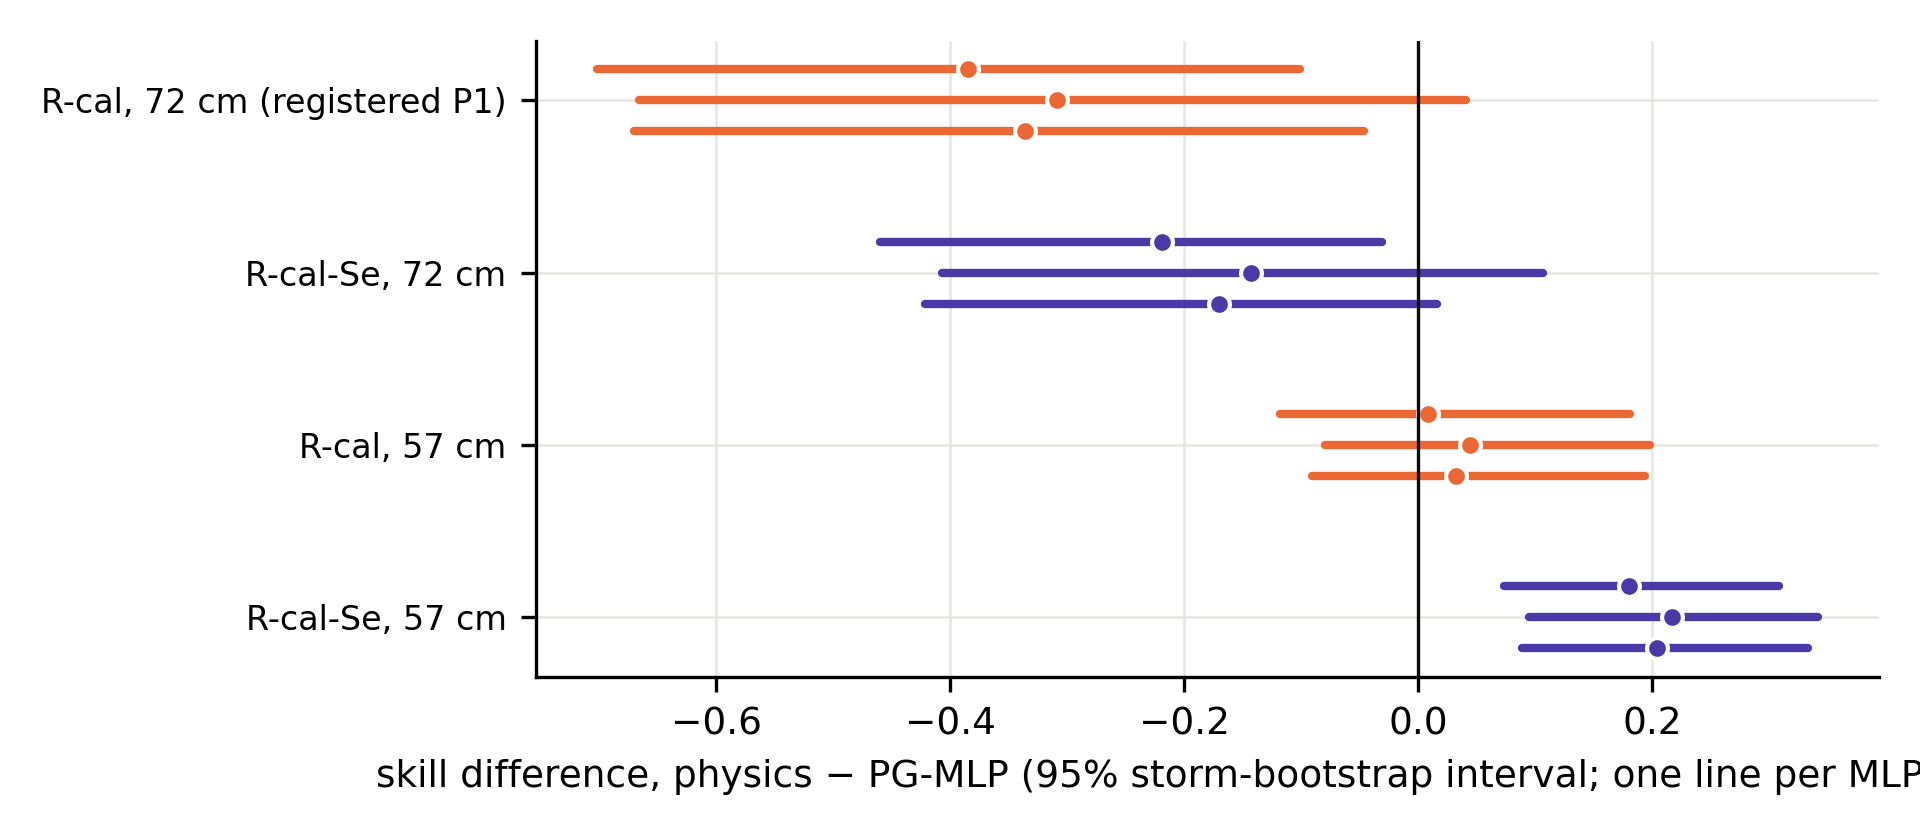

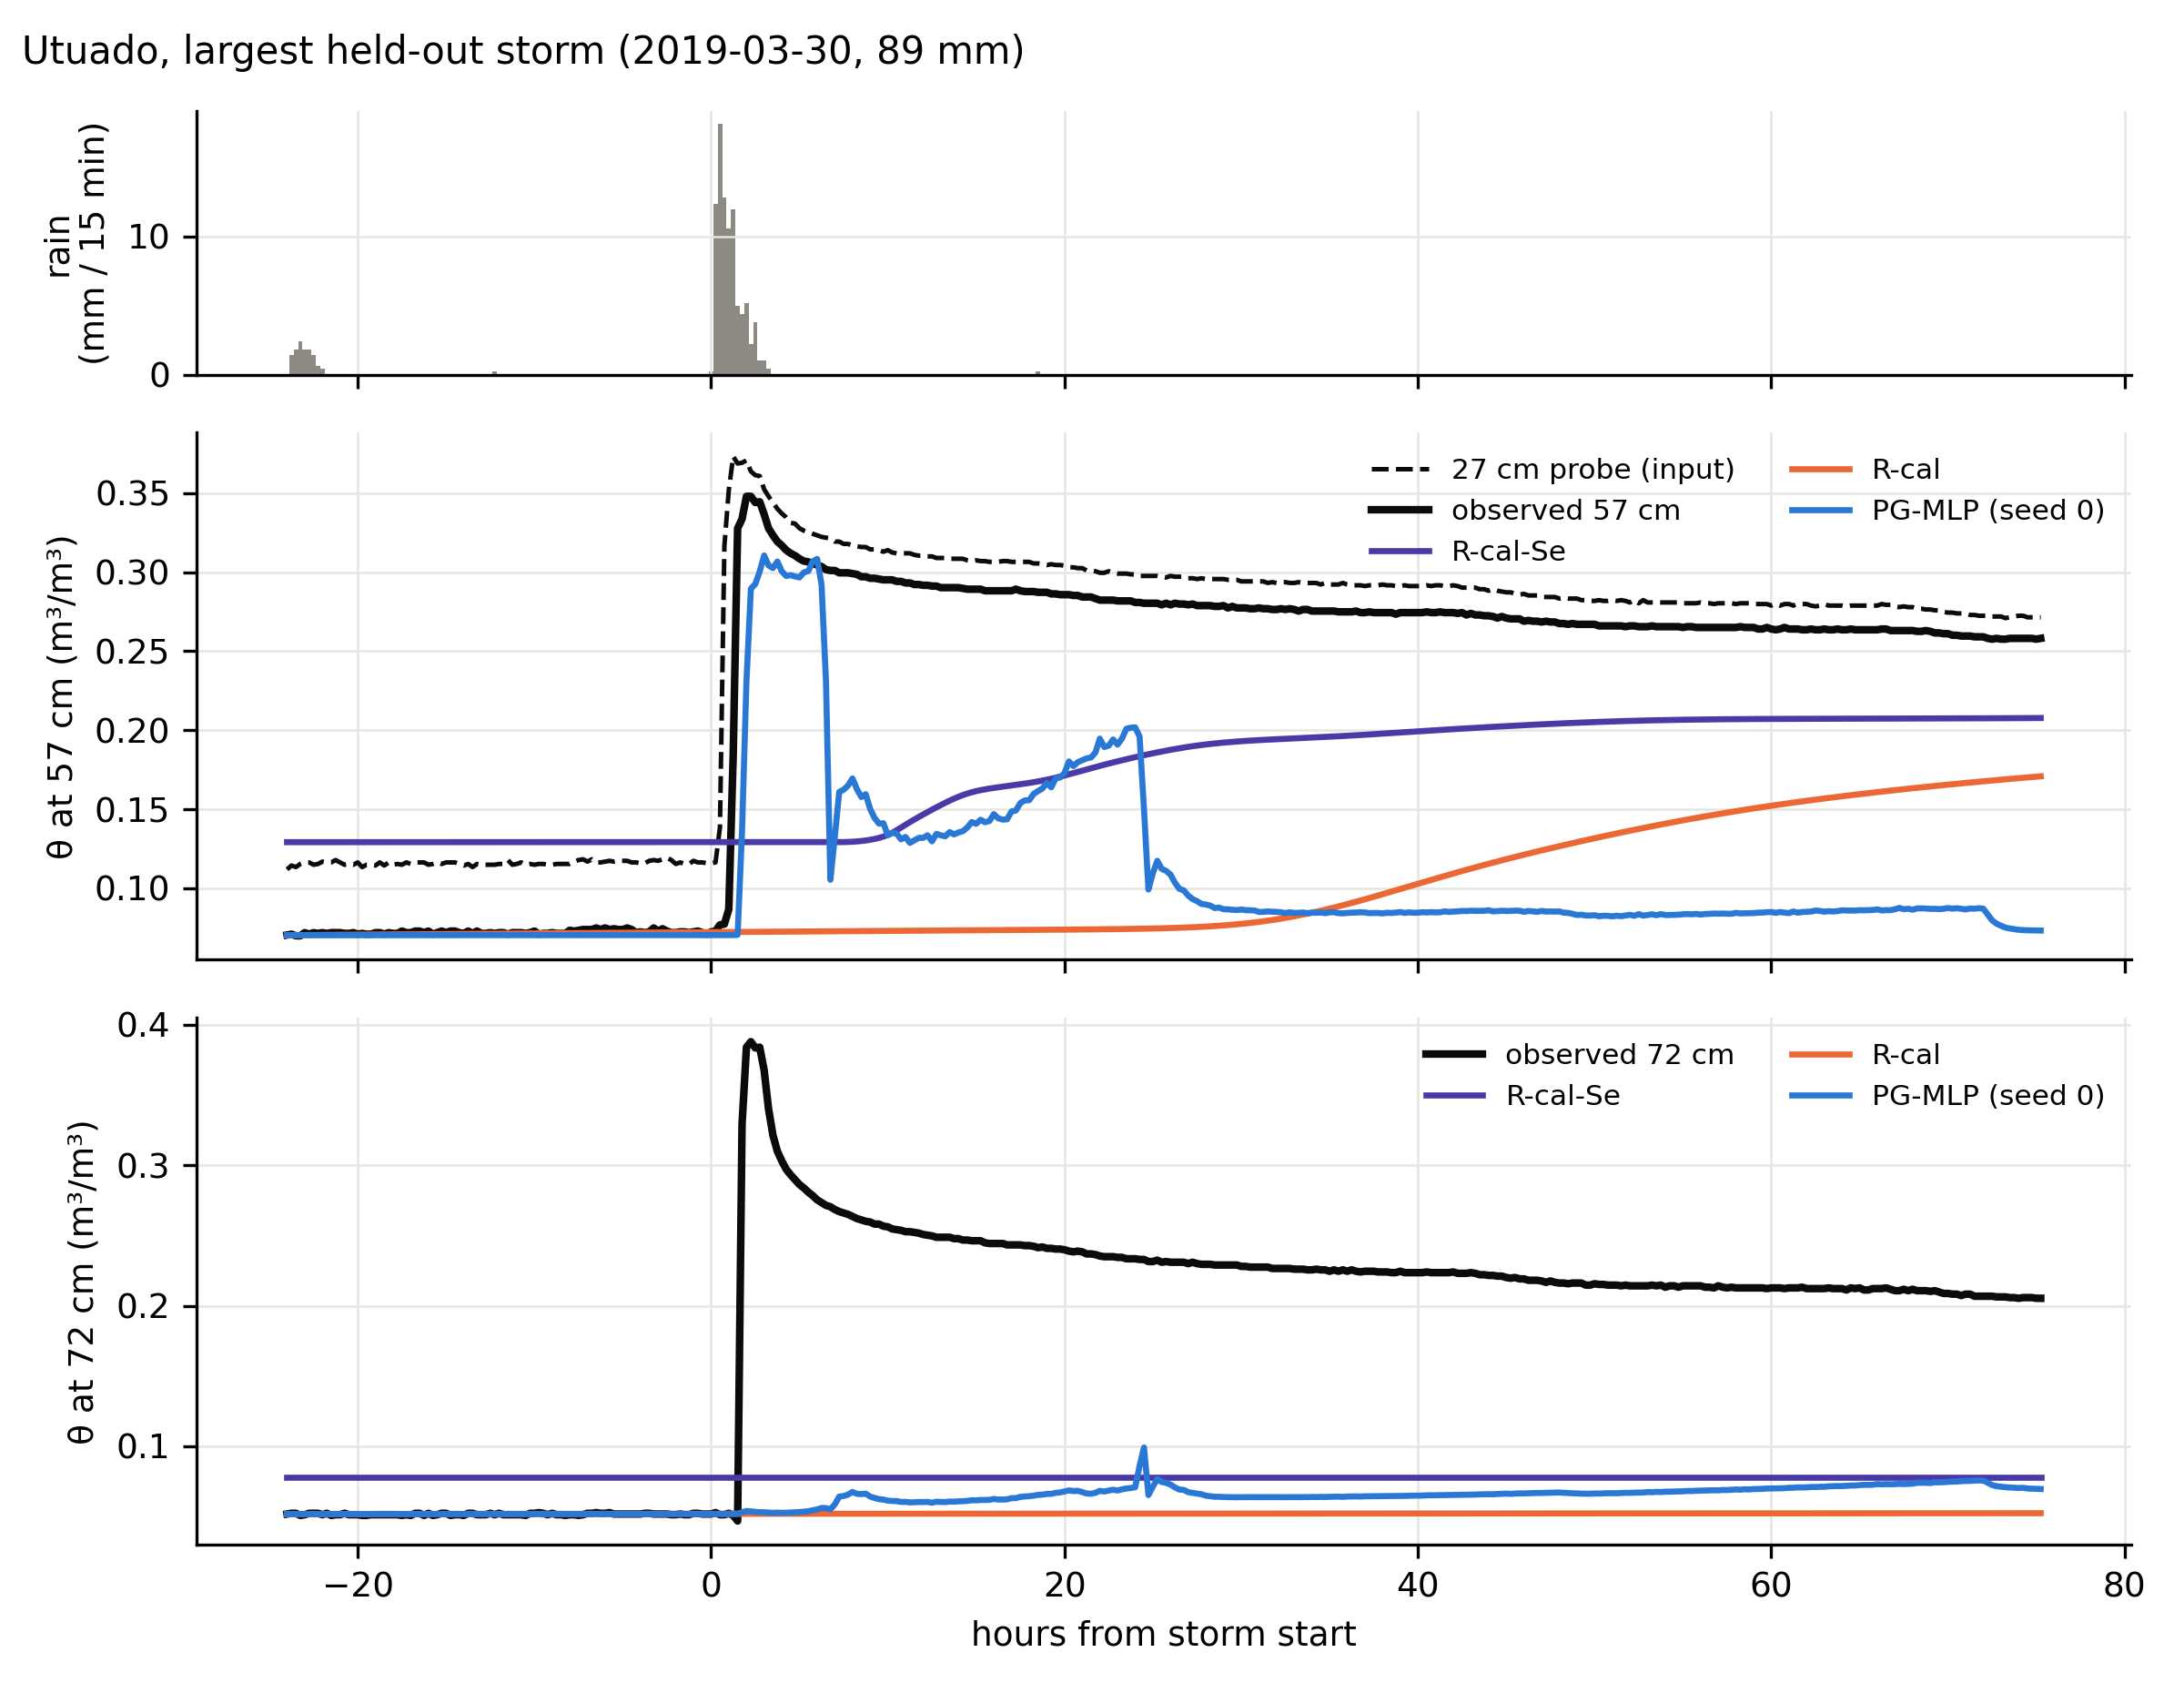

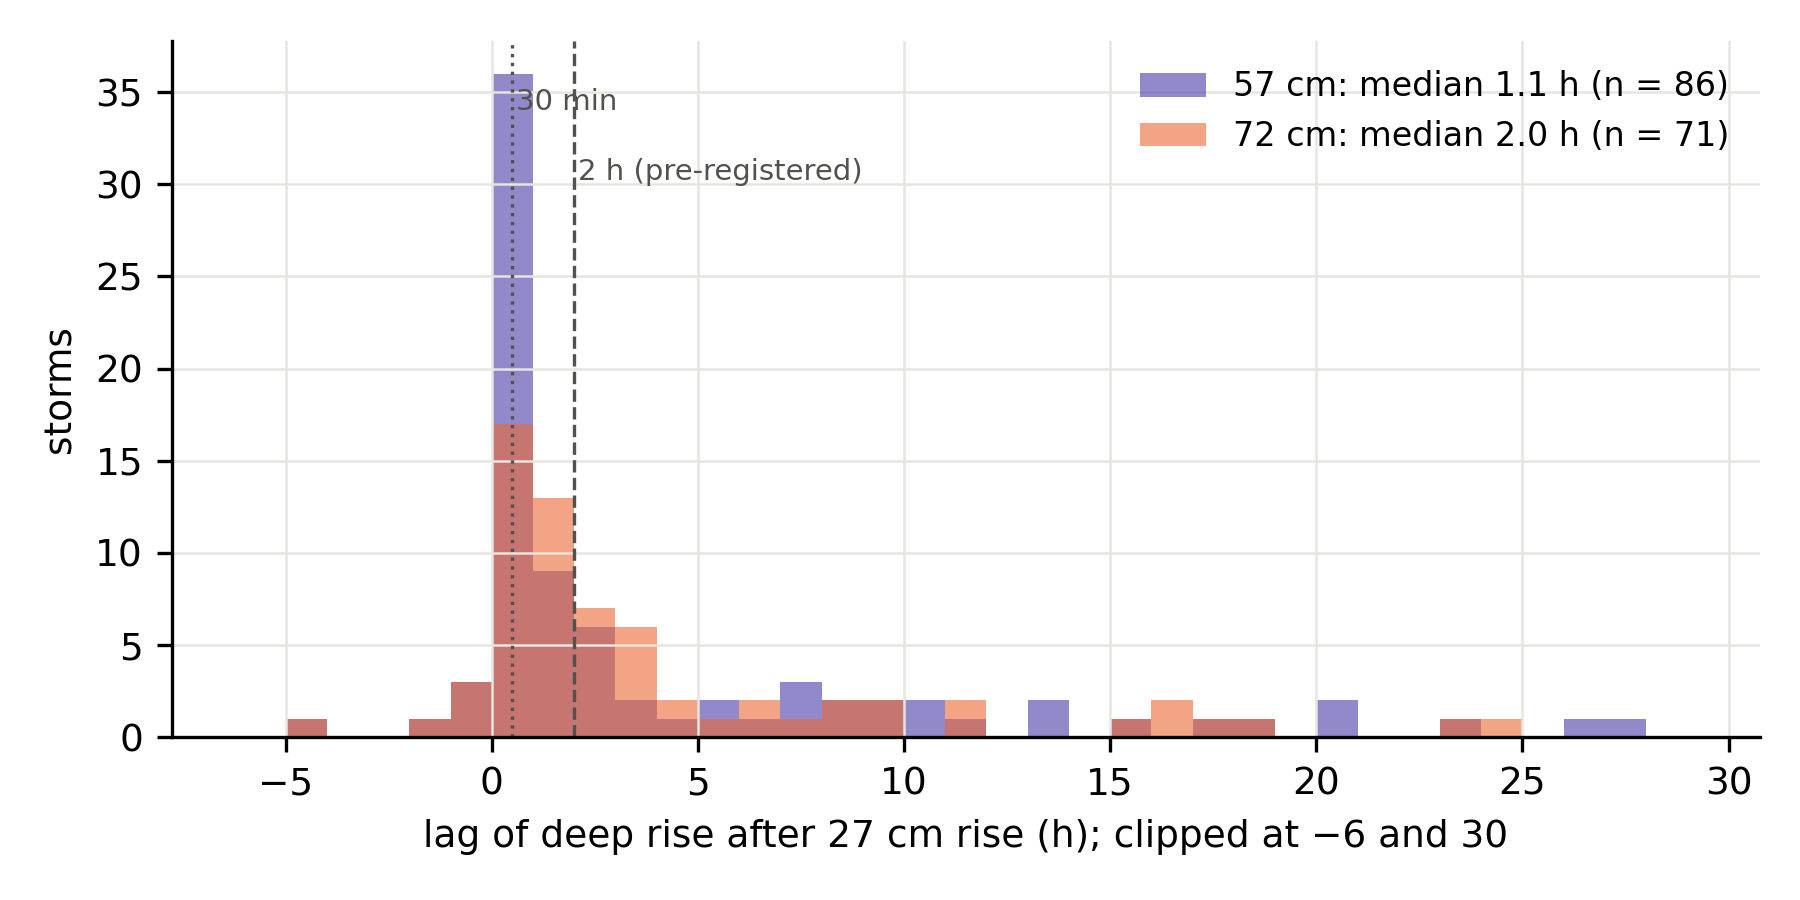

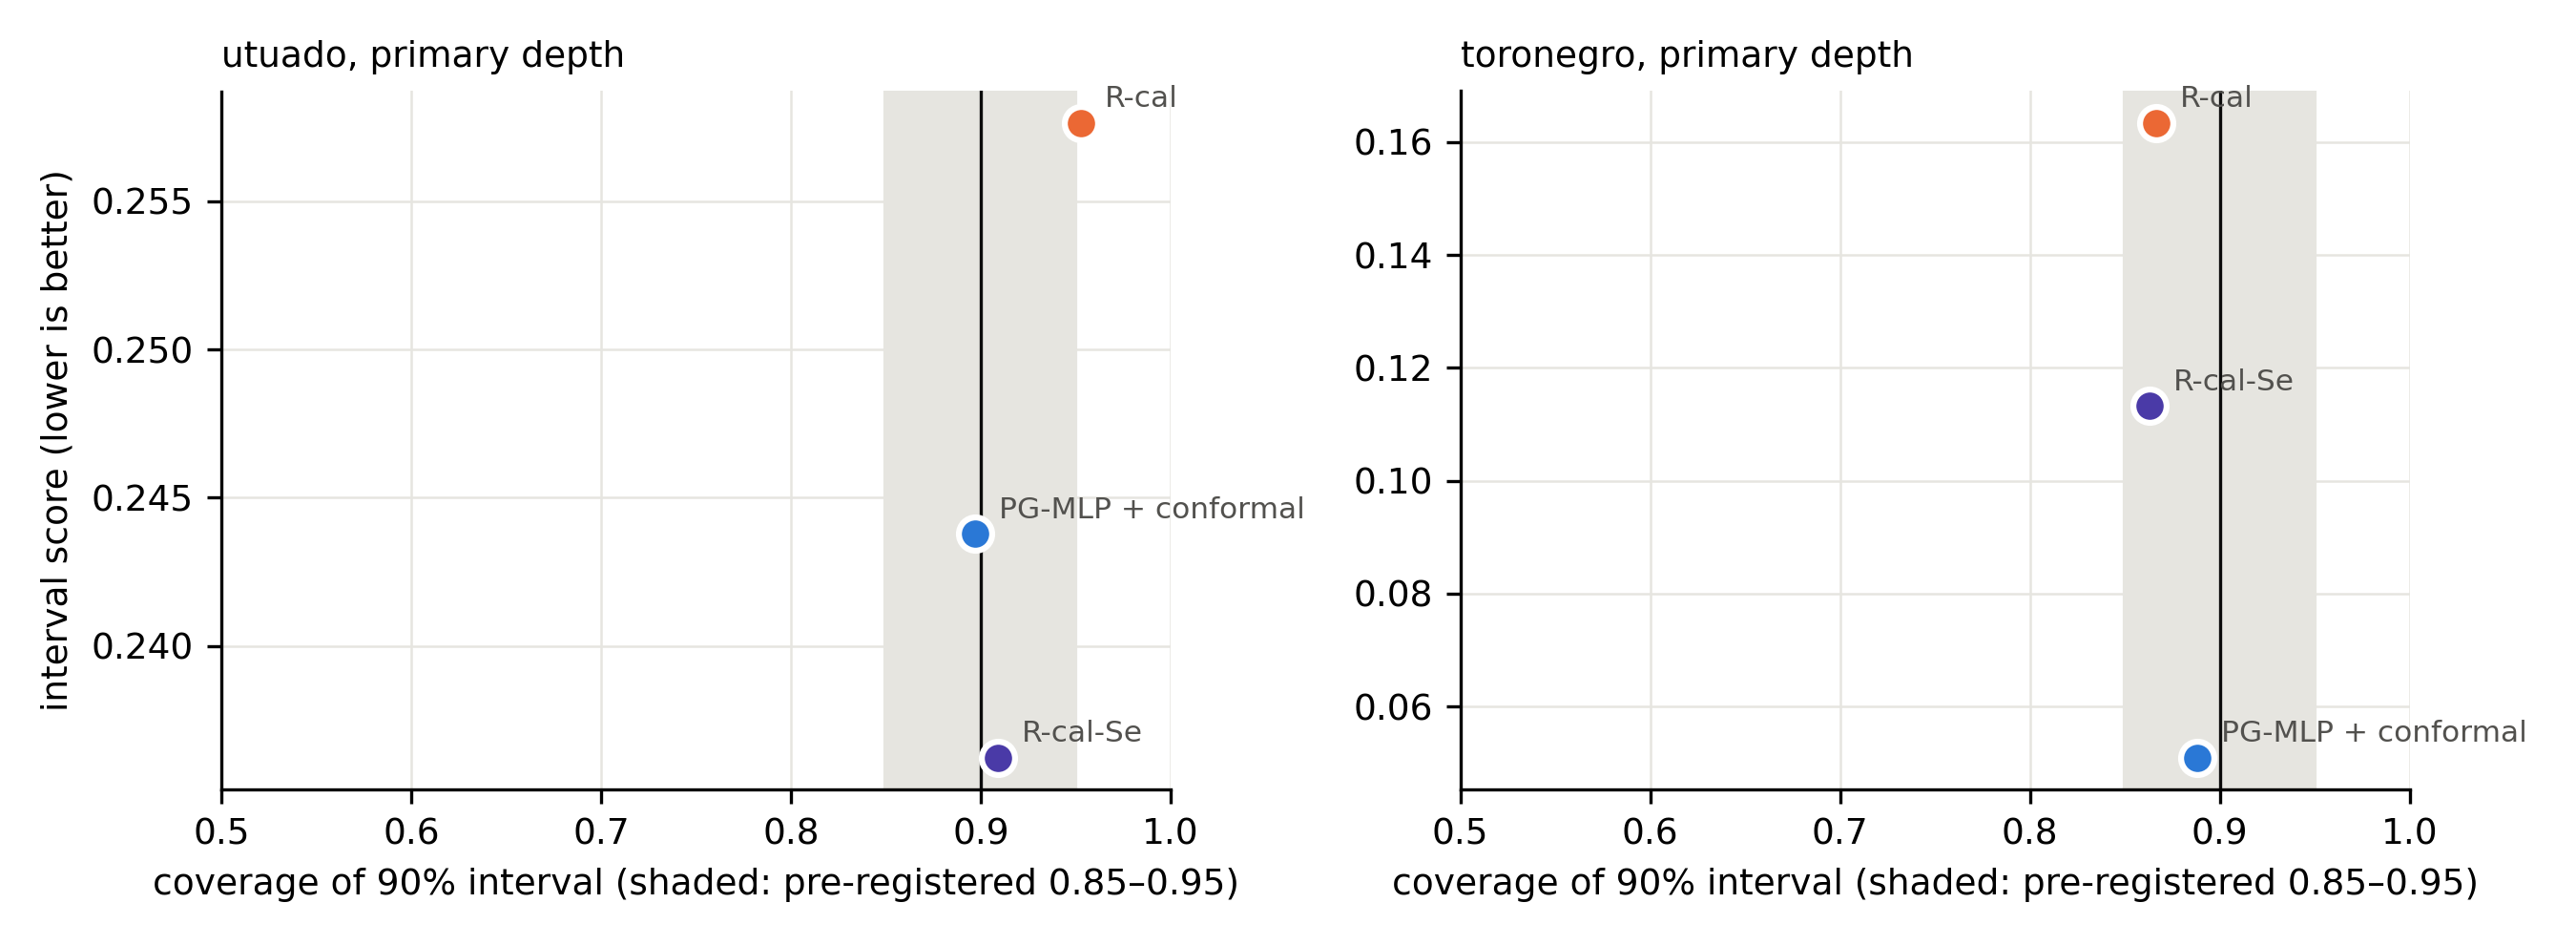

In [10]:
subprocess.run([sys.executable, 'figs_pr.py'], check=True, capture_output=True)
from IPython.display import Image, display
for f in ['figA_skill_by_depth', 'figB_bootstrap', 'figC_example_storm', 'figD_p2_lags', 'figE_p4']:
    if os.path.exists(f'figs/{f}.png'): display(Image(f'figs/{f}.png', width=800))